# Lunar Orbiter Simulation

Aaron Parsons

Simulates antenna temperature for a spinning spacecraft in circular lunar
orbit using `LunarOrbit` + `Simulator.sim_orbit_spin`.

**Sky model**: GSM2016 + 21 cm monopole + bright radio sources (3CR) + Sun + Earth.

**Lunar occultation**: `LunarOrbit.above_horizon()` provides a per-position
occultation mask; Moon-disk pixels are zeroed and then replaced with thermal
emission + reflected sky weighted by the frequency-dependent surface reflectivity.

**Algorithm**: SH+FFT spin sweep — all `N_PHI` spin angles from one FFT per
frequency per orbital position.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import healpy
from astropy.time import Time
from eigsep_terrain.reflectivity import terrain_reflection_coefficient, TERRAIN_TYPES

from eigsep_sim.beam import Beam
from eigsep_sim.lunar_orbit import LunarOrbit
from eigsep_sim.models import T21cmModel
from eigsep_sim.sim import Simulator
from eigsep_sim.src import SourceCatalog
from eigsep_sim.const import R_MOON

%matplotlib inline
CMAP = 'plasma'

## Configuration

In [3]:
NSIDE  = 32
NCHAN  = 64
freqs  = np.linspace(50e6, 150e6, NCHAN, dtype='float32')

N_ORBIT = 64   # orbital positions over one full orbit
N_PHI   = 32   # spin angles per orbital position

LUNAR_ALTITUDE = 8000e3   # altitude above lunar surface [m]

# Epoch for solar-system body positions (Sun, Earth).
# SS positions are fixed for the full orbit sweep — the orbital period (~2 h)
# is far shorter than the timescale on which Sun/Earth positions change.
OBS_TIME = Time('2025-06-01T00:00:00')

# Lunar surface terrain type.  Controls thermal emission and sky reflectivity
# of the Moon disk as seen from orbit.  Must be a key in
# eigsep_terrain.reflectivity.TERRAIN_TYPES.
TERRAIN_TYPE = 'lunar_regolith'
T_REGOLITH   = 200  # K, mean surface temperature

th_orbit_deg = np.linspace(0, 360, N_ORBIT, endpoint=False)
phi_deg      = np.linspace(0, 360, N_PHI,   endpoint=False)
ch_plot      = NCHAN // 2

## Beam

/home/aparsons/.local/share/mamba/envs/arp/lib/python3.11/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


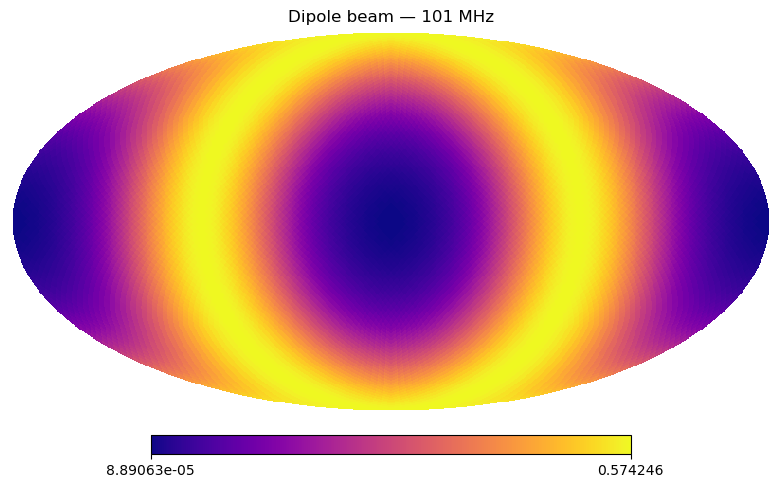

In [4]:
beam = Beam(freqs, beam_type='dipole', nside=NSIDE, peak_normalize=True)

fig = plt.figure(figsize=(10, 5))
healpy.mollview(beam.map[:, ch_plot], fig=fig, cmap=CMAP,
                title=f'Dipole beam — {freqs[ch_plot]/1e6:.0f} MHz')
plt.show()

## 21 cm signal model

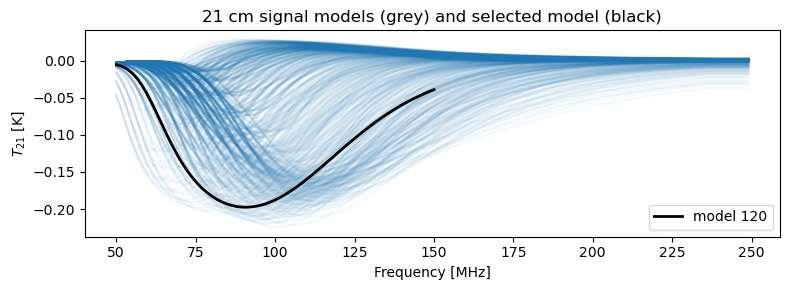

In [5]:
MODEL_INDEX = 120
t21cm  = T21cmModel()
T_21cm = t21cm(freqs, model_index=MODEL_INDEX).astype('float32')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t21cm._freqs / 1e6, t21cm._mdls.T, alpha=0.05, color='C0')
ax.plot(freqs / 1e6, T_21cm, 'k', lw=2, label=f'model {MODEL_INDEX}')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('$T_{21}$ [K]')
ax.set_title('21 cm signal models (grey) and selected model (black)')
ax.legend()
plt.tight_layout()
plt.show()

## Lunar surface reflectivity

Frequency-dependent amplitude reflectivity of the lunar regolith at normal
incidence, computed from the surface resistivity via the Fresnel coefficient.
In `sim_orbit_spin` this is used to weight the Moon-disk pixels:

$$T_{\rm Moon}(\nu) = (1 - |R(\nu)|)\,T_{\rm regolith} + |R(\nu)|\,T_{\rm sky,reflected}(\nu)$$

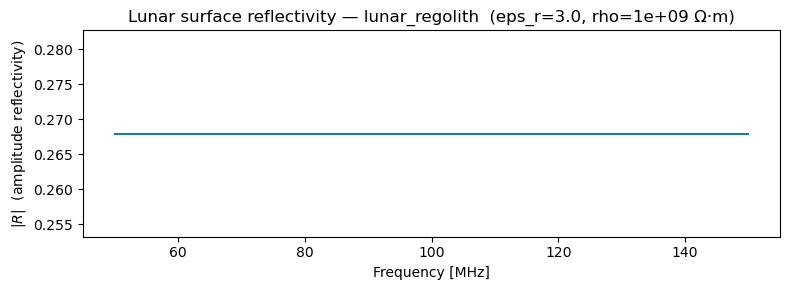

In [6]:
gamma = np.abs(terrain_reflection_coefficient(TERRAIN_TYPE, freqs.astype(np.float64))).astype('float32')
params = TERRAIN_TYPES[TERRAIN_TYPE]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(freqs / 1e6, gamma)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('$|R|$  (amplitude reflectivity)')
ax.set_title(
    f'Lunar surface reflectivity — {TERRAIN_TYPE}  '
    f'(eps_r={params["eps_r"]}, rho={params["resistivity_ohm_m"]:.0e} Ω·m)'
)
plt.tight_layout()
plt.show()

## Source catalog

The catalog is attached to `Simulator` and baked into a sky-map snapshot at
`OBS_TIME` when `sim_orbit_spin` is called.  Source positions relative to the
Moon (`observer_body='moon'`).

In [7]:
catalog = SourceCatalog(NSIDE, freqs, observer_body='moon')

catalog.add_sun()    # power-law radio spectrum, ~1 MK at 65 MHz
catalog.add_earth()  # thermal disc + FM-band contamination
catalog.add_vizier_3c(S_cut=100)   # bright 3CR radio sources

## Observer: LunarOrbit

100 km circular orbit; orbital plane = galactic x-y; spin about galactic z.

In [8]:
orbit = LunarOrbit(
    altitude       = LUNAR_ALTITUDE,
    rot_orbit_vec  = [0, 0, 1],      # orbital plane = galactic x-y
    rot_spin_vec   = [0, 0, 1],      # spin about galactic z
    start_pos      = [1, 0, 0],
    spin_period    = 600.0,          # 10 min
)
print(f'Orbital radius:  {orbit.orbital_radius/1e3:.1f} km  ({orbit.orbital_radius/R_MOON:.3f} R_Moon)')
print(f'Orbital period:  {orbit.orbital_period:.1f} s  ({orbit.orbital_period/3600:.2f} h)')

Orbital radius:  9737.4 km  (5.605 R_Moon)
Orbital period:  86204.6 s  (23.95 h)


## Simulator

In [ ]:
sim = Simulator(
    orbit, freqs, beam,
    nside    = NSIDE,
    gsm      = True,
    monopole = T_21cm,
    catalog  = catalog,
)

## Full sky model

The sky seen by the simulation: GSM + 21 cm monopole plus the
catalog sources baked at `OBS_TIME`.  This is the map that is resampled to the
topocentric frame and occultation-masked at each orbital position.

In [ ]:
full_sky = sim.sky_map(frame='gal', time=OBS_TIME)
# full_sky : (npix, NCHAN)  galactic frame, Kelvin

fig = plt.figure(figsize=(10, 5))
healpy.mollview(
    np.log10(sim.sky_map(frame='gal', time=OBS_TIME, channels=ch_plot).clip(1)),
    fig=fig, cmap=CMAP,
    title=f'Full sky model (log₁₀ K) — {freqs[ch_plot]/1e6:.0f} MHz',
)
plt.show()

## Lunar occultation mask at several orbital positions

In [ ]:
fig = plt.figure(figsize=(14, 8))
for i, th in enumerate([0, 90, 180, 270]):
    orbit.set_phases(np.deg2rad(th))
    mask = orbit.above_horizon(NSIDE).astype(float)
    healpy.mollview(
        mask, fig=fig, sub=(2, 2, i+1),
        title=f'Occultation mask, orbit = {th}°',
        cmap='gray', min=0, max=1,
    )
plt.tight_layout()
plt.show()

## Run: full orbit × spin sweep

`sim_orbit_spin` loops over `N_ORBIT` orbital phases (via `orbit.set_phases`),
applying the lunar occultation mask and adding Moon-disk emission at each step.
Catalog sources are baked at `OBS_TIME`; `resistivity_ohm_m` enables the
thermal+reflected Moon surface contribution.

In [ ]:
vis = sim.sim_orbit_spin(
    N_ORBIT, N_PHI,
    time         = OBS_TIME,
    Trx          = 50.0,
    T_regolith   = T_REGOLITH,
    terrain_type = TERRAIN_TYPE,
)
# vis shape: (N_ORBIT, N_PHI, NCHAN)
print(f'vis shape: {vis.shape}  dtype: {vis.dtype}')

## Results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spin-averaged T_ant vs orbital phase and frequency
vis_mean_phi = vis.mean(axis=1)   # (N_ORBIT, NCHAN)
im = axes[0].pcolormesh(freqs / 1e6, th_orbit_deg, vis_mean_phi, cmap=CMAP)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Orbital angle [°]')
axes[0].set_title('Spin-averaged $T_{ant}$ over one orbit')
plt.colorbar(im, ax=axes[0], label='T [K]')

# Spin variation at quarter-orbit
oi = N_ORBIT // 4
axes[1].plot(phi_deg, vis[oi, :, ch_plot])
axes[1].set_xlabel('Spin angle [°]')
axes[1].set_ylabel('$T_{ant}$ [K]')
axes[1].set_title(
    f'Spin sweep at orbital phase {th_orbit_deg[oi]:.0f}°,'
    f' f = {freqs[ch_plot]/1e6:.0f} MHz'
)

plt.tight_layout()
plt.show()

In [ ]:
# Spectral variation across all orbital × spin samples
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

T_flat = vis.reshape(-1, NCHAN)
T_mean = T_flat.mean(axis=0, keepdims=True)

axes[0].semilogy(freqs / 1e6, T_flat.T, alpha=0.05, color='C0')
axes[0].semilogy(freqs / 1e6, T_mean.T, 'k', lw=2, label='mean')
axes[0].set_ylabel('$T_{ant}$ [K]')
axes[0].set_title('All orbital × spin samples')
axes[0].legend()

axes[1].plot(freqs / 1e6, (T_flat / T_mean).T, alpha=0.05, color='C0')
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('$T / \\langle T \\rangle$')

plt.tight_layout()
plt.show()

In [ ]:
# Save results
if False:
    np.savez(
        'lunar_orbiter_sim_v001.npz',
        vis               = vis,
        freqs             = freqs,
        th_orbit_deg      = th_orbit_deg,
        phi_deg           = phi_deg,
        obs_time          = OBS_TIME.isot,
        altitude_m        = orbit.altitude,
        rot_orbit_vec     = orbit.rot_orbit_vec,
        rot_spin_vec      = orbit.rot_spin_vec,
        orbital_period_s  = orbit.orbital_period,
        spin_period_s     = orbit.spin_period,
        T_regolith_K      = T_REGOLITH,
        terrain_type      = TERRAIN_TYPE,
        T21cm_model       = MODEL_INDEX,
    )